## Import Modules

In [ ]:
import pandas as pd
import numpy as np
import time
import os
import copy
import json

# visualization modules
import seaborn as sns
import matplotlib.pyplot as plt
from PIL import Image

# pytorch modules
import torch
import torch.nn as nn
import torch.optim as optim
from torch.nn import functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import models
import torchvision.transforms as transforms

#for augmentation
import albumentations
from albumentations.pytorch.transforms import ToTensorV2

import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

## Load Dataset

In [ ]:
BASE_DIR = "../input/cassava-leaf-disease-classification/"

train = pd.read_csv(BASE_DIR+'train.csv')
train.head()

,image_id,label
0,1000015157.jpg,0
1,1000201771.jpg,3
2,100042118.jpg,1
3,1000723321.jpg,1
4,1000812911.jpg,3


In [ ]:
# Print the number of unique classes
print(train['label'].nunique())

5


In [ ]:
# Loading mapping of labels
with open(BASE_DIR+'label_num_to_disease_map.json') as f:
    mapping = json.loads(f.read())
    mapping = {int(k): v for k, v in mapping.items()}
mapping

{0: 'Cassava Bacterial Blight (CBB)',
 1: 'Cassava Brown Streak Disease (CBSD)',
 2: 'Cassava Green Mottle (CGM)',
 3: 'Cassava Mosaic Disease (CMD)',
 4: 'Healthy'}

In [ ]:
train['label_names'] = train['label'].map(mapping)
train.head()

,image_id,label,label_names
0,1000015157.jpg,0,Cassava Bacterial Blight (CBB)
1,1000201771.jpg,3,Cassava Mosaic Disease (CMD)
2,100042118.jpg,1,Cassava Brown Streak Disease (CBSD)
3,1000723321.jpg,1,Cassava Brown Streak Disease (CBSD)
4,1000812911.jpg,3,Cassava Mosaic Disease (CMD)


## Exploratory Data Analysis

In [ ]:
def plot_images(class_id, label, total_images=6):
    # get image ids corresponding to the target class id
    plot_list = train[train['label']==class_id].sample(total_images)['image_id'].tolist()

    labels = [label for i in range(total_images)]
    # dynamically set size for subplot
    size = int(np.sqrt(total_images))
    if size*size < total_images:
        size += 1

    # set figure size
    plt.figure(figsize=(15,15))

    # plot the image in subplot
    for index, (image_id, label) in enumerate(zip(plot_list, labels)):
        plt.subplot(size, size, index+1)
        image = Image.open(str(BASE_DIR+'train_images/'+image_id))
        print(image.size)
        plt.imshow(image)
        plt.title(label, fontsize=14)
        plt.axis('off')

    plt.show()

(800, 600)
(800, 600)
(800, 600)
(800, 600)
(800, 600)
(800, 600)


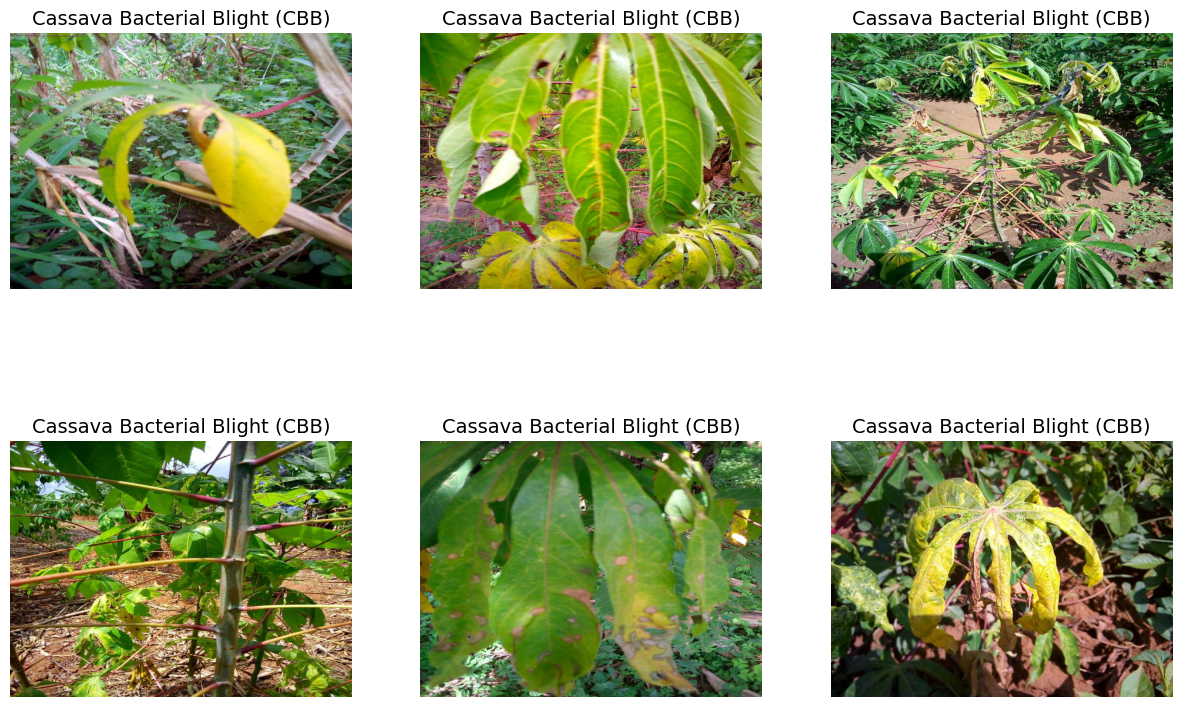

In [ ]:
plot_images(0, mapping[0], 6)

(800, 600)
(800, 600)
(800, 600)
(800, 600)
(800, 600)
(800, 600)


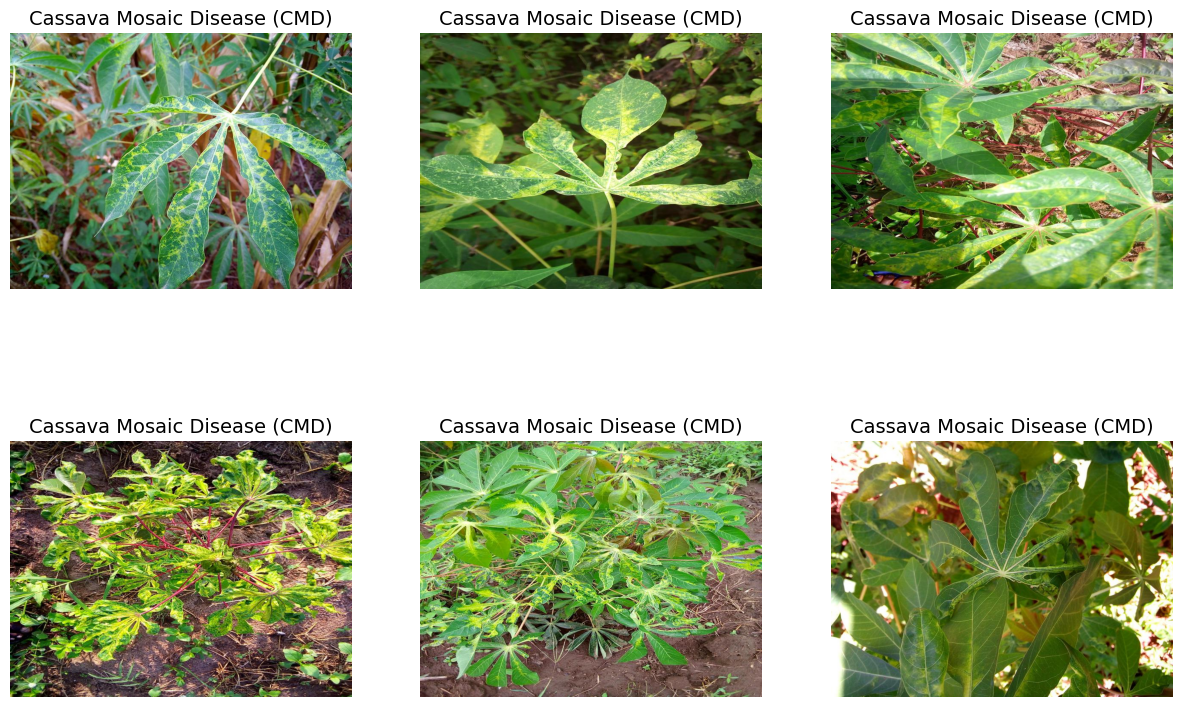

In [ ]:
plot_images(3, mapping[3], 6)

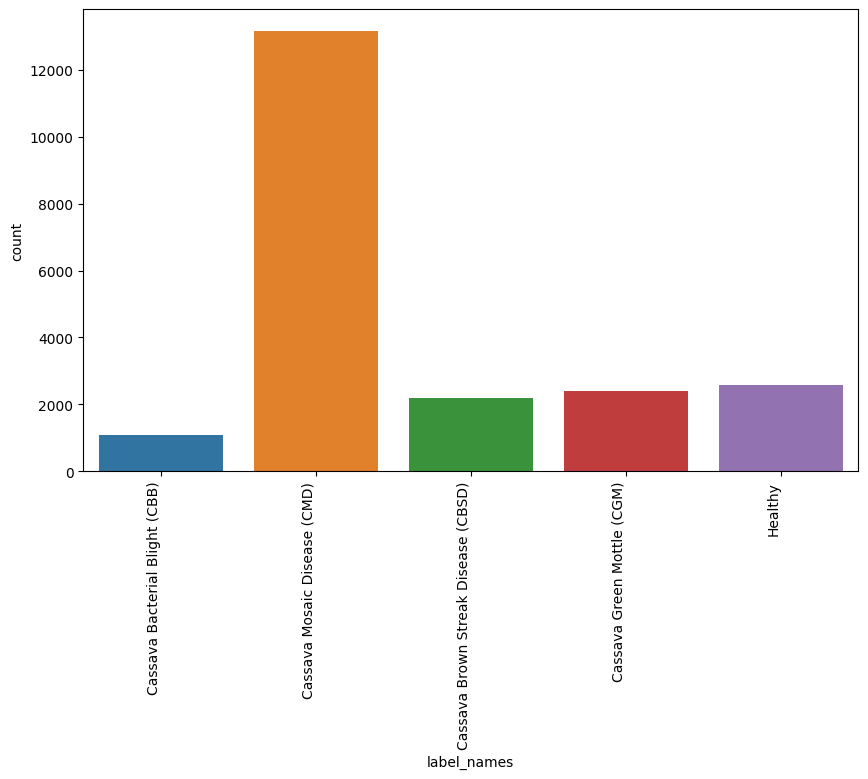

In [ ]:
# class distribution
plt.figure(figsize=(10, 6))
ax = sns.countplot(x=train['label_names'])
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='right')
plt.show()

## Adjust Configurations

In [ ]:
# DIM = (384, 384) #reduce the resolution of the image
DIM= (256,256) #reduce the resolution of the image
WIDTH, HEIGHT = DIM
NUM_CLASSES = 5
NUM_WORKERS = 24
TRAIN_BATCH_SIZE = 32
VAL_BATCH_SIZE = 32
TEST_BATCH_SIZE = 32
SEED = 1

DEVICE = 'cuda'

MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]

## Augmentation

In [ ]:
def get_test_transforms(value='val'):
    if value == 'train':
        return albumentations.Compose([


            albumentations.RandomResizedCrop(
                size=DIM,
                scale=(0.75, 1.0),
                ratio=(0.9, 1.1),
                p=1.0
            ),

            albumentations.ShiftScaleRotate(
                shift_limit=0.05,
                scale_limit=0.15,
                rotate_limit=25,
                border_mode=0,
                p=0.7
            ),

            albumentations.HorizontalFlip(p=0.5),

            # Color, lighting
            albumentations.ColorJitter(
                brightness=0.15,
                contrast=0.15,
                saturation=0.15,
                hue=0.05,
                p=0.7
            ),

            albumentations.RandomGamma(p=0.4),

            # Regularization
            albumentations.CoarseDropout(
                max_holes=4,
                max_height=24,
                max_width=24,
                fill_value=MEAN,
                p=0.3
            ),


            albumentations.Normalize(
                mean=MEAN,
                std=STD,
                max_pixel_value=255.0,
                always_apply=True
            ),
            ToTensorV2()
        ])

    elif value in ['val', 'test']:
        return albumentations.Compose([

            albumentations.Resize(HEIGHT, WIDTH),

            albumentations.Normalize(
                mean=MEAN,
                std=STD,
                max_pixel_value=255.0,
                always_apply=True
            ),
            ToTensorV2()
        ])

## Creating Class for Dataset Loader

In [ ]:
class CassavaDataset(Dataset):
    def __init__(self, image_ids, labels, augmentations=None, folder='train_images'):
        super().__init__()
        self.image_ids = image_ids
        self.labels = labels
        self.augmentations = augmentations
        self.folder = folder

    # returns the length
    def __len__(self):
        return len(self.image_ids)

    # return the image and label for that index
    def __getitem__(self, idx):
        img = Image.open(os.path.join(BASE_DIR, self.folder, self.image_ids[idx]))


        # convert to numpy array
        img = np.array(img)

        if self.augmentations:
            augmented = self.augmentations(image=img)
            img = augmented['image']

        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return img, label

## Split 70% train, 20% validation and 10% test

In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np #for the split calculation

#Here, We Split into a Temporary Training Set (90%) and the Final Test Set (10%)
X_temp, X_test, y_temp, y_test = train_test_split(
    train['image_id'],
    train['label'],
    test_size=0.10,
    random_state=42,
    stratify=train['label']
)


# the required test_size for this split is (0.20 / 0.90) ≈ 0.22
validation_size_ratio = 0.20 / (1 - 0.10)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=validation_size_ratio,
    random_state=42,
    stratify=y_temp
)
#now, this is the final result -> X_train is 70%, X_val is 20%, and X_test is 10%.

## Creating Dataloaders

In [ ]:
from torch.utils.data import WeightedRandomSampler #to give higher weight for rarer classes

def sampler_(labels):
    label_unique, counts = np.unique(labels, return_counts=True)
    print('Unique Labels', label_unique)
    weights = [sum(counts) / c for c in counts]
    sample_weights = [weights[w] for w in labels]  #This calculation ensures that rare classes get a higher weight
    sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)
    return sampler

train_sampler = sampler_(y_train)

Unique Labels [0 1 2 3 4]


In [ ]:
train_dataset = CassavaDataset(
    image_ids=X_train.values,
    labels=y_train.values,
    augmentations=get_test_transforms('train'),

)

train_loader = DataLoader(
    train_dataset,
    batch_size=TRAIN_BATCH_SIZE,
    num_workers=NUM_WORKERS,
    shuffle=True,
    sampler=train_sampler
)

val_dataset = CassavaDataset(
    image_ids=X_val.values,
    labels=y_val.values,
    augmentations=get_test_transforms('val'),

)

val_loader = DataLoader(
    val_dataset,
    batch_size=VAL_BATCH_SIZE,
    num_workers=NUM_WORKERS,
    shuffle=False
)

test_dataset = CassavaDataset(
    image_ids=X_test.values,
    labels=y_test.values,
    augmentations=get_test_transforms('val'),

)

test_loader = DataLoader(
    test_dataset,
    batch_size=TEST_BATCH_SIZE,
    num_workers=NUM_WORKERS,
    shuffle=False
)

loaders = {'train': train_loader, 'val': val_loader}

## Using CNN from Scratch

In [ ]:
class DeepCassavaNet(nn.Module):
    def __init__(self, num_classes=5):
        super(DeepCassavaNet, self).__init__()

        # Block 1: 3x256x256 -> 32x128x128

        # Block 2: 32x128x128 -> 64x64x64

        # Block 3: 64x64x64 -> 128x32x32

        # Block 4: 128x32x32 -> 256x16x16

        # Block 5: 256x16x16 -> 512x8x8

        # Block 6: 512x8x8 -> 512x4x4 (New block for second trial)

        #we added drop for only specific layers in 4th trial

        self.block1 = self._make_conv_block(3, 32)
        self.block2 = self._make_conv_block(32, 64)
        self.block3 = self._make_conv_block(64, 128)
        self.block4 = self._make_conv_block(128, 256, drop=True)
        self.block5 = self._make_conv_block(256, 512, drop=True)
        self.block6 = self._make_conv_block(512, 512, drop=True)


        # 1. Global Average Pooling (GAP), to decrese number of weights
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))

        # 2. Fully Connected Layers
        self.fc_dropout = nn.Dropout(0.5)
        self.classifier = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    #We Added nn.Dropout2d(0.1) here for regularization in 2nd trial
    def _make_conv_block(self, in_channels, out_channels, drop=False):
        layers = [
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),
            nn.MaxPool2d(2)
        ]
        if drop:
            layers.append(nn.Dropout2d(0.2))
        return nn.Sequential(*layers)


    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.block5(x)
        x = self.block6(x)

        # GAP and Flatten
        x = self.avgpool(x)
        x = x.view(x.size(0), -1) # Flattens to (Batch_size, 512)

        # Final Classification
        x = self.fc_dropout(x)
        x = self.classifier(x)

        return x

def getModel():
    net = DeepCassavaNet(num_classes=NUM_CLASSES)
    net = net.to(DEVICE)
    return net

In [ ]:
model = getModel()

## Using Adam Optimizer

In [ ]:
import math
# def cyclical_lr(stepsize, min_lr=3e-4, max_lr=3e-3):  #we removed this due to instability during trials

#     # Scaler: we can adapt this if we do not want the triangular CLR
#     scaler = lambda x: 1.

#     # Lambda function to calculate the LR
#     lr_lambda = lambda it: min_lr + (max_lr - min_lr) * relative(it, stepsize)

#     # Additional function to see where on the cycle we are
#     def relative(it, stepsize):
#         cycle = math.floor(1 + it / (2 * stepsize))
#         x = abs(it / stepsize - 2 * cycle + 1)
#         return max(0, (1 - x)) * scaler(cycle)

#     return lr_lambda

In [ ]:
criterion = nn.CrossEntropyLoss()

# optimizer = torch.optim.SGD(model.parameters(), lr=1, momentum=0.9)
# optimizer = torch.optim.Adam(model.parameters(), lr=1e-4) #added in third trial

# step_size = 4*len(train_loader)
# clr = cyclical_lr(step_size, min_lr=1e-3, max_lr=1e-2)
# clr = cyclical_lr(step_size, min_lr=1e-3, max_lr=5e-3) #we recduced max learning rate in 2nd trial, #removed in third trial
# scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, [clr]) #removed in third trial

optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4) #added in 4th trial

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=70
)

In [ ]:
# print(model)

In [ ]:
# find total parameters and trainable parameters
total_params = sum(p.numel() for p in model.parameters())
print(f'{total_params:,} total parameters')
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'{trainable_params:,} training parameters')

4,064,005 total parameters
4,064,005 training parameters


## Training and Validation Phase

In [ ]:
def train_model(model, dataloaders, criterion, optimizer, num_epochs=5, scheduler=None):
    start_time = time.time()

    val_acc_history = []
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    for epoch in range(num_epochs):
        print(f'Epoch {epoch}/{num_epochs - 1}')
        print('-' * 15)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(DEVICE)
                labels = labels.to(DEVICE)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    _, preds = torch.max(outputs, 1)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / len(dataloaders[phase].dataset)
            epoch_acc = running_corrects.double() / len(dataloaders[phase].dataset)

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

            if phase == 'val':
                val_acc_history.append(epoch_acc)


        if scheduler is not None:
            scheduler.step()

        print()

    elapsed_time = time.time() - start_time
    print(f'Training completes in {elapsed_time // 60:.0f}m {elapsed_time % 60:.0f}s')
    print(f'Best Val Acc: {best_acc:.4f}')

    model.load_state_dict(best_model_wts)
    return model, val_acc_history

In [ ]:
# train the model
model, accuracy = train_model(model=model, dataloaders=loaders, criterion=criterion, optimizer=optimizer, num_epochs=70, scheduler=scheduler)

Epoch 0/69
---------------
train Loss: 1.4472 Acc: 0.3680
val Loss: 1.9304 Acc: 0.2042

Epoch 1/69
---------------
train Loss: 1.3074 Acc: 0.4564
val Loss: 1.2352 Acc: 0.5208

Epoch 2/69
---------------
train Loss: 1.2389 Acc: 0.4976
val Loss: 1.2875 Acc: 0.5075

Epoch 3/69
---------------
train Loss: 1.1734 Acc: 0.5301
val Loss: 1.1704 Acc: 0.5724

Epoch 4/69
---------------
train Loss: 1.1160 Acc: 0.5615
val Loss: 1.0048 Acc: 0.6273

Epoch 5/69
---------------
train Loss: 1.0791 Acc: 0.5770
val Loss: 1.3635 Acc: 0.5009

Epoch 6/69
---------------
train Loss: 1.0455 Acc: 0.5917
val Loss: 1.1439 Acc: 0.5888

Epoch 7/69
---------------
train Loss: 1.0173 Acc: 0.6069
val Loss: 0.9047 Acc: 0.6909

Epoch 8/69
---------------
train Loss: 1.0148 Acc: 0.6093
val Loss: 1.0270 Acc: 0.6121

Epoch 9/69
---------------
train Loss: 0.9658 Acc: 0.6286
val Loss: 1.0284 Acc: 0.6250

Epoch 10/69
---------------
train Loss: 0.9660 Acc: 0.6302
val Loss: 0.7978 Acc: 0.7089

Epoch 11/69
---------------
tra

In [ ]:
# save the model and model weights
torch.save(model, '/kaggle/working/best_model_trial4.pth')
torch.save(model.state_dict(), '/kaggle/working/best_model_weights_trial4.pth')

## Testing Phase

In [ ]:
# empty the cache from cuda device to free memory
torch.cuda.empty_cache()

In [ ]:
def test_model(model, dataloader):
    # Set model to evaluation mode
    model.eval()
    running_corrects = 0

    for inputs, labels in dataloader: #we here move data to cpu
        inputs = inputs.to(DEVICE)
        labels = labels.to(DEVICE)

        with torch.no_grad(): # Essential for testing
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

        running_corrects += torch.sum(preds == labels.data)

    test_acc = running_corrects.double() / len(dataloader.dataset)
    print('Final Test Acc: {:.4f}'.format(test_acc))

test_model(model, test_loader)

Final Test Acc: 0.8444
